# Packed (scale/offset) NetCDF files

Files whose variables are stored as int16 with `scale_factor`/`add_offset`. pyramids unpacks transparently on read; note the dtype/scale columns in the variable table below.

In [1]:
%matplotlib inline
from pathlib import Path
import tempfile

import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon

from pyramids.netcdf import NetCDF, UgridDataset
from pyramids.feature import FeatureCollection

DATA = Path('../../../../examples/data/netcdf/samples')

2026-06-18 13:01:22 | INFO | pyramids.base.config | Logging is configured.


## `cf__20v__1d3-3d17.nc`

ECMWF surface fields: 17 packed int16 variables sharing one (time, lat, lon) grid. Longitudes run 0–360.

**Open the file and inspect the container**

In [2]:
nc = NetCDF.read_file(DATA / 'cf__20v__1d3-3d17.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ..\..\..\..\examples\data\netcdf\samples\cf__20v__1d3-3d17.nc
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [3]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (3):
    latitude             size=73
    longitude            size=144
    time                 size=12
  Variables (20):
    blh dims=('/time', '/latitude', '/longitude') shape=(12, 73, 144) dtype=int16 unit='m' scale=0.10873938334451697 offset=3570.143670551653
    cp dims=('/time', '/latitude', '/longitude') shape=(12, 73, 144) dtype=int16 unit='m' scale=4.82483645945993e-07 offset=0.01580857665942046
    e dims=('/time', '/latitude', '/longitude') shape=(12, 73, 144) dtype=int16 unit='m of water' scale=1.1670245190791643e-07 offset=-0.0023219971296410792
    hcc dims=('/time', '/latitude', '/longitude') shape=(12, 73, 144) dtype=int16 unit='(0 - 1)' scale=1.5259720441921504e-05 offset=0.49998474028055817
    latitude dims=('/latitude',) shape=(73,) dtype=float32 unit='degrees_north'
    lcc dims=('/time', '/latitude', '/longitude') shape=(12, 73, 144) dtype=int16 unit='(0 - 1)' scale=1.5259720441921504e-05 offset=0.49998

**Global attributes**

In [4]:
nc.global_attributes

{'Conventions': 'CF-1.0',
 'history': '2004-09-15 17:04:29 GMT by mars2netcdf-0.92'}

**Plot the variable** (a 2-D slice is auto-selected for >2-D variables)

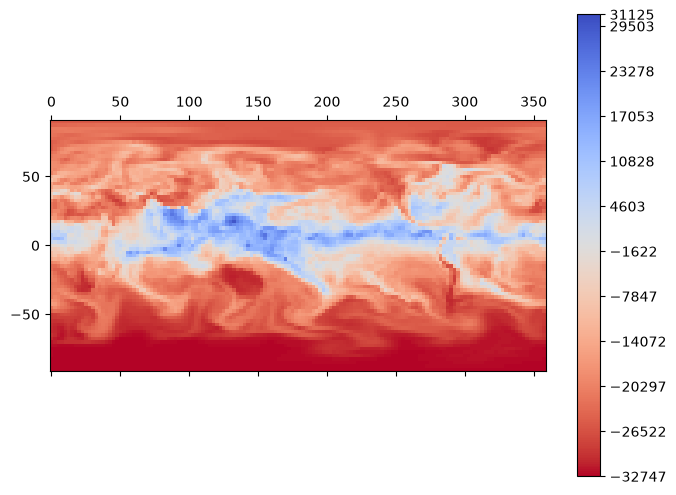

In [5]:
nc.plot(variable='tcw')

**Wrap longitude to −180–180** — this grid spans 0–360 (Pacific-centred). `wrap_longitude` re-frames it to the −180–180 (Greenwich-centred) convention; we wrap the selected variable, then plot the re-centred map.

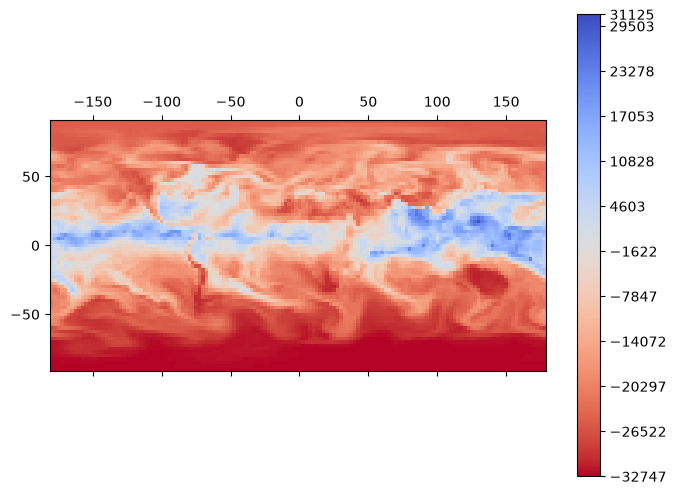

In [6]:
nc.get_variable('tcw').wrap_longitude().plot()

**Retrieve the underlying data**

In [7]:
var = nc.get_variable('tcw')
data = var.read_array()
print('shape:', data.shape)
print('min / mean / max:', float(np.nanmin(data)), float(np.nanmean(data)), float(np.nanmax(data)))

shape: (12, 73, 144)
min / mean / max: -32767.0 -24796.70115106545 32767.0


**Reduce a dimension** — collapse the time axis to its mean

In [8]:
time_mean = nc.reduce('time', how='mean')
print('dimensions after reducing time:', dict(time_mean.dimension_sizes))

dimensions after reducing time: {'x': 144, 'y': 73}


**Add a variable** — derive a 2-D field and append it as a new variable

In [9]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d, geo=var.geotransform, epsg=var.epsg or 4326,
    variable_name='tcw_slice0', path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'tcw_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['blh', 'cp', 'e', 'hcc', 'lcc', 'lsp', 'mcc', 'msl', 'p10u', 'p10v', 'p2d', 'p2t', 'tcc', 'tco3', 'tcw', 'tcw_slice0', 'tcwv', 'tp']


**Remove a variable**

In [10]:
nc.remove_variable('tcw_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['blh', 'cp', 'e', 'hcc', 'lcc', 'lsp', 'mcc', 'msl', 'p10u', 'p10v', 'p2d', 'p2t', 'tcc', 'tco3', 'tcw', 'tcwv', 'tp']


**Crop every variable with one polygon** — `crop` masks the whole container against the polygon in a single call (cells outside become no-data) and returns a new `NetCDF`. We use a 5-pointed **star** so the cropped region is unmistakable in the plot below.

2026-06-18 13:01:23 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


2026-06-18 13:01:24 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


2026-06-18 13:01:24 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


2026-06-18 13:01:24 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


2026-06-18 13:01:24 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


...

2026-06-18 13:01:25 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


2026-06-18 13:01:25 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


2026-06-18 13:01:25 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


2026-06-18 13:01:25 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


2026-06-18 13:01:25 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


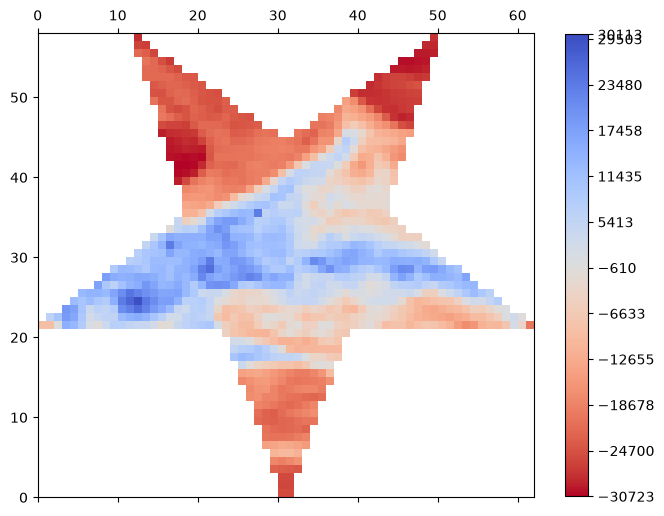

In [11]:
xmin, ymin, xmax, ymax = var.total_bounds
cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
radius = min(xmax - xmin, ymax - ymin) * 0.45
star = Polygon([
    (cx + (radius if i % 2 == 0 else radius * 0.4) * np.cos(np.pi / 2 + i * np.pi / 5),
     cy + (radius if i % 2 == 0 else radius * 0.4) * np.sin(np.pi / 2 + i * np.pi / 5))
    for i in range(10)
])
polygon = gpd.GeoDataFrame(geometry=[star], crs=var.epsg or 4326)
cropped = nc.crop(FeatureCollection(polygon))
cropped.plot(variable='tcw')

**Save the result to a new NetCDF file**

In [12]:
out = work / 'cropped.nc'
cropped.to_file(str(out))
print('saved cropped container to', out.name, '->', out.exists())

saved cropped container to cropped.nc -> True
